# Enroll a new device from a `.nam` capture (no recording needed)

Same goal as [`enroll_new_device.ipynb`](enroll_new_device.ipynb) — fit an
**embedding** for one device against a frozen one-to-many run — but the device's
response is **synthesized**, not recorded, so there is nothing to capture and
nothing to align. **You provide one thing: `NAM_PATH`.** The notebook picks up
the TONE3000 sweep from `data/raw/nam_sweep/`, renders it through the capture to
build the wet/dry pair itself, and fits the embedding on it (Phase 5,
`openamp.emulate.enroll.enroll_pair`).

Why this is simpler than the recorded-pair flow:

- **No reamp latency, no alignment.** The wet sweep is a deterministic render of
  the dry sweep, so the pair is sample-aligned *by construction* — the #1 error
  source in the recorded flow (a constant wet/dry offset the embedding can't
  absorb) simply doesn't exist here.
- **No capture session.** Any of the ~2,000 `.nam` files under `data/captures/`
  can be enrolled straight from disk: a device the frozen run never saw becomes a
  conditioning vector in a couple of minutes.

The `.nam` is the ground truth — the wet sweep it produces is exactly what the
embedding learns to reproduce, and the A/B at the end pits the enrolled
one-to-many model against that same `.nam` render.

1. Set `NAM_PATH` to the capture to enroll (and pick the run via `RUN_DIR`).
2. Run all cells: the sweep is auto-located, rendered through the `.nam` at its
   native level, split into **NAM's own train/val regions** (the trainer's layout
   from `nam/train/core.py` — lead-in dropped, blips kept, ESR scored on the
   dedicated 9 s tail rather than a blind last-`VAL_FRAC` slice; see the sections
   cell), and enrolled on a pure pre-emphasized-ESR objective (`STFT_WEIGHT = 0` —
   measured to be essential here, see the notes).
3. Listen: dry → wet (`.nam` target) → enrolled-model prediction on the val region.
4. Export: writes a pasteable `profile.json` (`{name, run, dim, embedding}`)
   for the morph plugin.

- Kernel: the **open-amp3000** conda env (Python 3.10).
- Runs on **CPU** by default so it never competes with a live training run.
- Artifacts land in `<run>/enroll/pairs/<NAME>/` — the same layout as the
  recorded flow, so `load_pair_model(RUN_DIR, NAME)` rebuilds the playable
  model and `profile.json` is the plugin-ready embedding.

In [1]:
import os
from pathlib import Path

# run from the repo root so the config's relative data paths resolve
if not Path('configs').is_dir() and (Path.cwd().parent / 'configs').is_dir():
    os.chdir(Path.cwd().parent)
print('cwd:', Path.cwd())

import numpy as np

from openamp.core.config import load_config

# ---- input (the only thing you set) ---------------------------------------
NAM_PATH = Path('data/captures/manual/Marshall 1959BJA LOW 2.nam')   # the .nam capture to enroll

# ---- defaults you rarely touch --------------------------------------------
RUN_DIR    = Path('results/emulate/nam_a2_tanh_ch16_256')     # frozen run to enroll against
NAME       = None    # artifact name (enroll/pairs/<NAME>/); None -> from NAM_PATH
DRY_SOURCE = 'sweep' # what drives the .nam: 'sweep' (T3K capture signal) or
                     #   'corpus' (clean train DI — the frozen net's own input
                     #   distribution; measured ~2x lower val ESR, see notes)
SWEEP_PATH = None    # override the sweep file; None -> auto-find in data/raw/nam_sweep/

# ---- knobs ------------------------------------------------------------------
DEVICE      = 'cuda'  # 'cuda' when the GPU is free (used for BOTH the .nam render and the fit)
PAIRS       = 500    # optimization windows per epoch (steps/epoch = PAIRS / BATCH)
BATCH       = 8      # fit batch size; None -> the run's own (nam_a2_256 sets 32).
                     #   The fit runs fp32 (no autocast, unlike the trainer), so a
                     #   run's own batch costs ~2x its training activation memory
                     #   here: 32 OOMs a 12 GB card, 8 fits alongside the .nam.
                     #   Only memory and steps/epoch change, not the fit itself.
EPOCHS      = 400     # max epochs
LR          = 5e-3
VAL_FRAC    = 0.1    # last 10% of the pair is held back for val
EARLY_STOP  = 40      # stop after N epochs with no val-ESR gain; <= 0 -> run all EPOCHS
STFT_WEIGHT = 0.0    # loss = preemph-ESR + this * multi-res STFT. Keep 0.0: with the
                     #   run's trained weight (1.0) the STFT term dominates the pair
                     #   fit and val ESR RISES from the baseline (see notes)
LR_PATIENCE = 5      # ReduceLROnPlateau: epochs with no val gain before LR *= LR_FACTOR
LR_FACTOR   = 0.5    #   (measured: slower decay does NOT move the floor -- see notes)

cfg = load_config()
if NAME is None:
    NAME = f'nam_{NAM_PATH.stem}'
print(f'run={RUN_DIR.name}  sample_rate={cfg.sample_rate}  enroll_name={NAME}')

cwd: /m/home/home3/37/thieun1/unix/Project/AllAmpsOnMe
run=nam_a2_tanh_ch16_256  sample_rate=48000  enroll_name=nam_Marshall 1959BJA LOW 2


In [2]:
from openamp.dsp.nam import parse_nam

# Select the .nam model. Any capture under data/captures/ can be enrolled; set
# NAM_PATH above to one of these and re-run from here.
captures = sorted(cfg.captures_dir.rglob('*.nam'))
print(f'{len(captures)} .nam captures under {cfg.captures_dir}; e.g.:')
for p in captures[:8]:
    print('   ', p.relative_to(cfg.captures_dir))

if not NAM_PATH.is_file():
    raise FileNotFoundError(f'NAM_PATH not found: {NAM_PATH}')
info = parse_nam(NAM_PATH)
print(f'\nselected: {NAM_PATH}')
print(f"  arch={info['architecture']}  sample_rate={info['sample_rate']}  "
      f"has_weights={info['has_weights']}")
meta = info.get('metadata') or {}
shown = {k: meta[k] for k in ('name', 'modeled_by', 'gear_make', 'gear_model',
                              'tone_type') if k in meta}
if shown:
    print('  metadata:', shown)

2079 .nam captures under data/captures; e.g.:
    1053/420096.nam
    1053/82190.nam
    1066/420088.nam
    1066/82108.nam
    1066/82109.nam
    1066/82110.nam
    1066/82111.nam
    1066/82112.nam

selected: data/captures/manual/Marshall 1959BJA LOW 2.nam
  arch=SlimmableContainer  sample_rate=48000  has_weights=True
  metadata: {'name': 'Marshall 1959BJA LOW 2', 'modeled_by': 'rickcollinsproductions', 'gear_make': 'Marshall 1959BJA', 'gear_model': 'Marshall 1959BJA', 'tone_type': 'T3K-Null'}


In [3]:
from openamp.core import manifest as manifests
from openamp.dsp.audio import peak_dbfs, read_audio, resample, rms_dbfs


def find_sweep():
    # The dry sweep that drives the .nam. Use SWEEP_PATH if set, else the
    # canonical v3_0_0.wav, else any .wav dropped into data/raw/nam_sweep/
    # (this is where the TONE3000 sweep lives) -- so a fresh checkout just works.
    if SWEEP_PATH is not None:
        return Path(SWEEP_PATH)
    if cfg.nam_sweep_path.is_file():
        return cfg.nam_sweep_path
    hits = sorted(cfg.nam_sweep_path.parent.glob('*.wav'))
    if hits:
        return hits[0]
    raise FileNotFoundError(
        f'no sweep found in {cfg.nam_sweep_path.parent} -- drop the TONE3000 '
        'sweep .wav there, or set SWEEP_PATH')


if DRY_SOURCE == 'corpus':
    # Stitch the clean train split: the exact input distribution the frozen net
    # trained on (per-file leveled, peak-capped). Measured ~2x lower val ESR
    # than the sweep on wavenet_a2 -- see the notes cell.
    corpus = manifests.read_manifest(cfg.corpus_manifest_path, manifests.CORPUS_COLUMNS)
    files = [cfg.clean_split_dir('train') / f'{fid}.{cfg.output_format}'
             for fid in corpus[corpus['split'] == 'train']['file_id']]
    parts = []
    for p in files:
        if p.is_file():
            x, sr = read_audio(p)
            parts.append(resample(x, sr, cfg.sample_rate))
    if not parts:
        raise FileNotFoundError('no clean train renders -- run `openamp corpus` '
                                "or use DRY_SOURCE='sweep'")
    dry = np.concatenate(parts).astype(np.float32)
    dry_src = f'clean corpus train split ({len(parts)} files)'
else:
    sweep_path = find_sweep()
    x, sr = read_audio(sweep_path)
    dry = resample(x, sr, cfg.sample_rate).astype(np.float32)
    dry_src = str(sweep_path)

# NATIVE level, deliberately un-normalized. TONE3000 trained the .nam with the
# sweep played as-is, and the sweep's stats (rms ~-22, peak ~-0.1 dBFS) already
# sit inside the frozen net's training input range (rms -22..-19, peak <= -1).
# RMS-matching the whole file to -18 dBFS overshoots (+4 dB -> +4 dBFS peaks,
# out of distribution for both nets) because the file's quiet sections drag the
# whole-file RMS down.
print(f'dry source: {dry_src}')
print(f'dry: {len(dry) / cfg.sample_rate:.1f}s   rms {rms_dbfs(dry):6.1f} dBFS  '
      f'peak {peak_dbfs(dry):6.1f} dBFS  (native level)')

dry source: data/raw/nam_sweep/T3K-sweep-v3.wav
dry: 190.0s   rms  -22.1 dBFS  peak   -0.1 dBFS  (native level)


.nam loaded: sr=48000Hz  R=6347  sha=8728c53f7a4f
wet: rms  -26.9 dBFS  peak   -6.6 dBFS   pair=190.0s


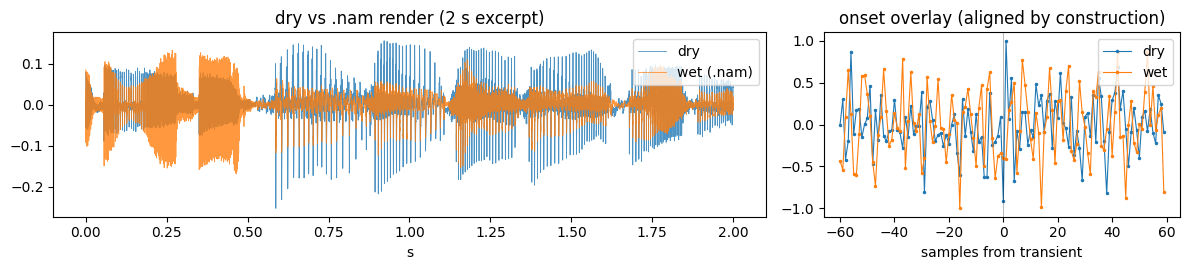

In [4]:
import matplotlib.pyplot as plt

from openamp.corpus.render import chunked_forward
from openamp.dsp import nam as nam_dsp

model = nam_dsp.load_model(NAM_PATH, device=DEVICE)
print(f'.nam loaded: sr={model.sample_rate}Hz  R={model.receptive_field}  '
      f'sha={model.nam_sha256[:12]}')


def render_through_nam(x):
    # Stream the dry through the .nam with real left-context (resample-aware).
    # Same whole-file, chunked driver the corpus render stage uses, so the wet
    # sweep is bit-identical to a single full-file forward.
    if model.sample_rate == cfg.sample_rate:
        return chunked_forward(model.forward, x, model.receptive_field, cfg.chunk_samples)
    xr = resample(x, cfg.sample_rate, model.sample_rate)
    chunk = int(round(cfg.chunk_seconds * model.sample_rate))
    yr = chunked_forward(model.forward, xr, model.receptive_field, chunk)
    return resample(yr, model.sample_rate, cfg.sample_rate)


wet = render_through_nam(dry).astype(np.float32)
n = min(len(dry), len(wet))
dry, wet = dry[:n].copy(), wet[:n].copy()          # equal length for enroll_pair
print(f'wet: rms {rms_dbfs(wet):6.1f} dBFS  peak {peak_dbfs(wet):6.1f} dBFS   '
      f'pair={n / cfg.sample_rate:.1f}s')

# The wet is a deterministic render of the dry -> sample-aligned by construction
# (no reamp latency). Left: 2 s overview.  right: onset overlay, each trace
# peak-normalized; the edges sit on the black line with zero offset (nothing to
# correct) -- unlike a recorded pair, where this plot is where you catch latency.
o = n // 3
end = min(o + 2 * cfg.sample_rate, n)
k = int(np.argmax(np.abs(np.diff(dry)))); w = 60    # sharpest dry edge, +-60 smp
z0, z1 = max(k - w, 0), min(k + w, n)
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 2.8),
                               gridspec_kw={'width_ratios': [2, 1]})
axl.plot(np.arange(end - o) / cfg.sample_rate, dry[o:end], lw=0.6, alpha=0.8, label='dry')
axl.plot(np.arange(end - o) / cfg.sample_rate, wet[o:end], lw=0.6, alpha=0.8, label='wet (.nam)')
axl.set_xlabel('s'); axl.set_title('dry vs .nam render (2 s excerpt)')
axl.legend(loc='upper right')
nd = dry[z0:z1] / (np.max(np.abs(dry[z0:z1])) + 1e-9)
nw = wet[z0:z1] / (np.max(np.abs(wet[z0:z1])) + 1e-9)
axr.plot(np.arange(z0, z1) - k, nd, marker='.', ms=3, lw=0.8, label='dry')
axr.plot(np.arange(z0, z1) - k, nw, marker='.', ms=3, lw=0.8, label='wet')
axr.axvline(0, color='k', lw=0.5, alpha=0.4)
axr.set_xlabel('samples from transient')
axr.set_title('onset overlay (aligned by construction)')
axr.legend(loc='upper right')
plt.tight_layout(); plt.show()

NAM v3_0_0 layout (190.0s):
  lead-in     0.0-  10.0s   discarded (not trained on)
  blips    @ 10.5s, 11.5s      latency cal (kept in train)
  TRAIN      10.0- 181.0s   171.0s
  VAL       181.0- 190.0s     9.0s held out
  (old blind split trained 0-171.0s incl. lead-in+blips, val last 19.0s)


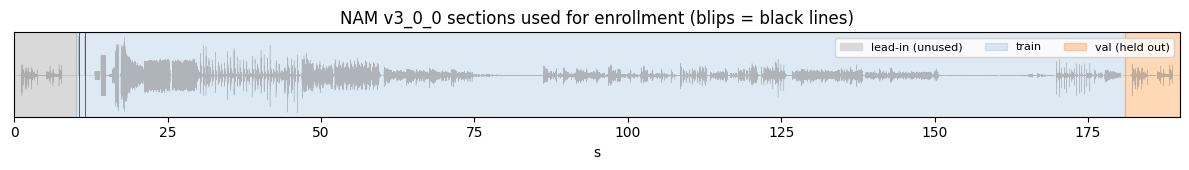

In [5]:
from openamp.emulate.enroll import nam_signal_regions

# Follow NAM's OWN train/val split instead of blindly training on the whole file
# and calling the last VAL_FRAC "validation". The v3 sweep is structured: a 10 s
# lead-in (settle/silence), the calibration blips, ~171 s of training content,
# then a dedicated 9 s validation block at the tail. NAM's trainer trains on
# [0:10 .. -0:09] (lead-in dropped, blips kept) and reports ESR on that final 9 s
# -- so we validate on genuinely held-out, musically-distinct content, and stop
# drawing training windows from the silent lead-in.
#
# This applies ONLY to the standard sweep. A stitched corpus DI (DRY_SOURCE=
# 'corpus') has no sections, so there we fall back to the plain VAL_FRAC split.
regions = nam_signal_regions(n, sample_rate=cfg.sample_rate) if DRY_SOURCE == 'sweep' else None
sr = cfg.sample_rate

if regions is None:
    why = 'corpus DI' if DRY_SOURCE != 'sweep' else f'{n} not a recognized NAM signal'
    print(f'no NAM sections ({why}) -> plain val_frac={VAL_FRAC} time split')
else:
    tr, vr, li, bl = regions['train'], regions['val'], regions['lead_in'], regions['blips']
    print(f"NAM {regions['version']} layout ({n / sr:.1f}s):")
    print(f'  lead-in  {li[0]/sr:6.1f}-{li[1]/sr:6.1f}s   discarded (not trained on)')
    print(f'  blips    @ {bl[0]/sr:.1f}s, {bl[1]/sr:.1f}s      latency cal (kept in train)')
    print(f'  TRAIN    {tr[0]/sr:6.1f}-{tr[1]/sr:6.1f}s   {(tr[1]-tr[0])/sr:5.1f}s')
    print(f'  VAL      {vr[0]/sr:6.1f}-{vr[1]/sr:6.1f}s   {(vr[1]-vr[0])/sr:5.1f}s held out')
    print(f'  (old blind split trained 0-{ (n-round(VAL_FRAC*n))/sr:.1f}s incl. lead-in+blips, '
          f'val last {round(VAL_FRAC*n)/sr:.1f}s)')

    t = np.arange(n) / sr
    fig, ax = plt.subplots(figsize=(12, 1.8))
    ax.plot(t, dry, lw=0.3, alpha=0.5, color='0.5')
    ax.axvspan(li[0]/sr, li[1]/sr, color='0.85', label='lead-in (unused)')
    ax.axvspan(tr[0]/sr, tr[1]/sr, color='tab:blue', alpha=0.15, label='train')
    ax.axvspan(vr[0]/sr, vr[1]/sr, color='tab:orange', alpha=0.30, label='val (held out)')
    for b in bl:
        ax.axvline(b/sr, color='k', lw=0.7, alpha=0.6)
    ax.set_xlabel('s'); ax.set_yticks([]); ax.set_xlim(0, n/sr)
    ax.legend(loc='upper right', ncol=3, fontsize=8)
    ax.set_title(f"NAM {regions['version']} sections used for enrollment (blips = black lines)")
    plt.tight_layout(); plt.show()

**Why the section split (adapting NAM's protocol, not blindly training on the sound).**
NAM's standardized sweep isn't uniform audio — `nam/train/core.py` defines exact
boundaries for v3.0.0 (@ 48 kHz): a **lead-in** `[0 : 480_000]` (0:00–0:10) that
its trainer *discards*, **calibration blips** at 504_000 / 552_000 (used only for
reamp-latency alignment — here lag = 0 by construction, so they're just kept in
the train slice), the **training** region `[480_000 : −432_000]` (0:10–3:01), and
a dedicated **validation** block `[−432_000 :]` (the last 9 s) that NAM reports
its final ESR on. We mirror that split exactly.

The old default (`val_frac=0.1`) ignored all of this: it drew training windows
across the whole file — including the 10 s silent lead-in and the blips — and
treated the last 19 s as "validation," ~half of which is training-character
audio. Following NAM's own regions means the embedding never fits on the lead-in,
and val ESR is measured on genuinely held-out, musically-distinct content —
directly comparable to what NAM's trainer would report. *(The sweep-vs-DI val-ESR
figures in the notes below were measured under the old blind split; expect them to
shift under this one — worth re-measuring.)* Corpus DI has no such structure, so
`DRY_SOURCE='corpus'` automatically falls back to the `VAL_FRAC` time split.

In [6]:
from openamp.emulate.enroll import enroll_pair

# train/val regions come from NAM's own layout when we have the standard sweep
# (see the sections cell); regions=None -> enroll_pair falls back to VAL_FRAC.
metrics = enroll_pair(cfg, RUN_DIR, dry, wet, name=NAME, pairs=PAIRS,
                      epochs=EPOCHS, lr=LR, device=DEVICE, val_frac=VAL_FRAC,
                      batch_size=BATCH,
                      train_region=regions['train'] if regions else None,
                      val_region=regions['val'] if regions else None,
                      early_stop_patience=EARLY_STOP, stft_weight=STFT_WEIGHT,
                      plateau_patience=LR_PATIENCE, plateau_factor=LR_FACTOR,
                      sources={'nam': str(NAM_PATH), 'nam_sha256': model.nam_sha256,
                               'dry': dry_src, 'lag_samples': 0,
                               'signal': regions['version'] if regions else f'val_frac={VAL_FRAC}'})
metrics

[enroll-pair] run=nam_a2_tanh_ch16_256 arch=film_wavenet name=nam_Marshall 1959BJA LOW 2 pair=190.0s train 10.0-181.0s val 181.0-190.0s (9.0s) pairs/epoch=500 batch=8 lr=0.005 stft_weight=0
[enroll-pair] baseline val_esr=1.17891 (init=table_mean)
  e00 step      50 loss 0.12948 esr 0.12948 stft 1.0128    57 smp/s
[enroll epoch 00] val_esr=0.06103 best=0.06103 lr=5.0e-03  *
  e01 step     100 loss 0.07578 esr 0.07578 stft 0.7124    58 smp/s
[enroll epoch 01] val_esr=0.02833 best=0.02833 lr=5.0e-03  *
  e02 step     150 loss 0.28828 esr 0.28828 stft 0.8138    57 smp/s
[enroll epoch 02] val_esr=0.04619 best=0.02833 lr=5.0e-03
  e03 step     200 loss 0.06465 esr 0.06465 stft 0.5503    55 smp/s
  e03 step     250 loss 0.09712 esr 0.09712 stft 0.5507    59 smp/s
[enroll epoch 03] val_esr=0.06659 best=0.02833 lr=5.0e-03
  e04 step     300 loss 0.04114 esr 0.04114 stft 0.4297    59 smp/s
[enroll epoch 04] val_esr=0.01811 best=0.01811 lr=5.0e-03  *
  e05 step     350 loss 0.26690 esr 0.26690 st

{'run': 'nam_a2_tanh_ch16_256',
 'name': 'nam_Marshall 1959BJA LOW 2',
 'pairs': 500,
 'epochs': 400,
 'batch_size': 8,
 'epochs_run': 78,
 'best_epoch': 37,
 'lr': 0.005,
 'seed': 1234,
 'init': 'table_mean',
 'stft_weight': 0.0,
 'pair_seconds': 190.0,
 'val_seconds': 9.0,
 'train_region': [480000, 8688000],
 'val_region': [8688000, 9120000],
 'init_val_esr_pooled': 1.178906,
 'best_val_esr_pooled': 0.01368,
 'val_esr_render_raw': 0.009148,
 'val_esr_render_preemph': 0.013915,
 'sources': {'nam': 'data/captures/manual/Marshall 1959BJA LOW 2.nam',
  'nam_sha256': '8728c53f7a4fbde247fdc4fb3720935b2739df16bc9ea76bb4bfc9bf35a7173e',
  'dry': 'data/raw/nam_sweep/T3K-sweep-v3.wav',
  'lag_samples': 0,
  'signal': 'v3_0_0'},
 'elapsed_s': 805.7}

val region (9.0s):  raw ESR 0.0091   pre-emph 0.0139
dry (input)


wet (.nam target)


prediction (enrolled one-to-many)


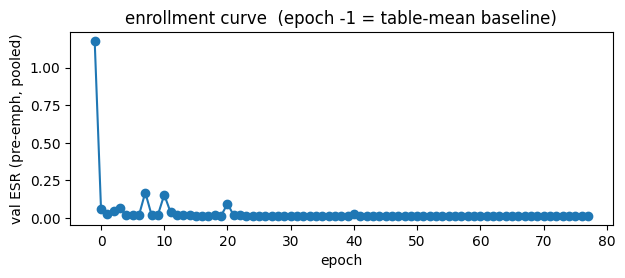

In [7]:
import pandas as pd
from IPython.display import Audio, display

from openamp.emulate.enroll import load_pair_model, render_dry

log = pd.read_csv(RUN_DIR / 'enroll' / 'pairs' / NAME / 'enroll_log.csv')
ax = log.plot(x='epoch', y='val_esr', marker='o', figsize=(7, 2.5), legend=False)
ax.set_ylabel('val ESR (pre-emph, pooled)')
ax.set_title('enrollment curve  (epoch -1 = table-mean baseline)')

enrolled, blob = load_pair_model(RUN_DIR, NAME, device=DEVICE)
R = enrolled.receptive_field
lo = n - int(round(metrics['val_seconds'] * cfg.sample_rate))
ctx = min(R, lo)                                  # real left-context from train side
pred = render_dry(enrolled, dry[lo - ctx:], device=DEVICE)[ctx:]

print(f"val region ({metrics['val_seconds']:.1f}s):  "
      f"raw ESR {metrics['val_esr_render_raw']:.4f}   "
      f"pre-emph {metrics['val_esr_render_preemph']:.4f}")
for label, sig in (('dry (input)', dry[lo:]),
                   ('wet (.nam target)', wet[lo:]),
                   ('prediction (enrolled one-to-many)', pred)):
    print(label)
    display(Audio(sig, rate=cfg.sample_rate, normalize=False))

In [8]:
import json

from openamp.emulate.export import export_profile

# Pasteable embedding profile for the morph plugin: {aaom_profile, name, run,
# dim, embedding}. `run` is the checkpoint's sha8, so the plugin can refuse a
# profile enrolled against a different network. Same schema/CLI as
# `openamp emulate-export-profile <run> --pair <name>`.
profile = export_profile(RUN_DIR, pair_name=NAME, name=NAME)
profile_path = RUN_DIR / 'enroll' / 'pairs' / NAME / 'profile.json'
profile_path.write_text(json.dumps(profile), encoding='utf-8')
print(f'wrote {profile_path}  ({profile_path.stat().st_size} bytes)')
print(f"  name={profile['name']!r}  run={profile['run']}  dim={profile['dim']}")

wrote results/emulate/nam_a2_tanh_ch16_256/enroll/pairs/nam_Marshall 1959BJA LOW 2/profile.json  (5603 bytes)
  name='nam_Marshall 1959BJA LOW 2'  run=fd77e8e5  dim=256


**Notes**

- **The `.nam` is the ground truth.** Enrollment can only be as faithful as the
  frozen one-to-many net's capacity allows: the val-render ESR above measures the
  enrolled model against the *same* `.nam` render it trained on, so it is a clean
  read on how well a single conditioning vector reproduces this amp.
- **Alignment is free here.** Because the wet sweep is a render of the dry, lag
  is exactly 0 — the onset overlay is a formality, not a correction step. This is
  the big win over [`enroll_new_device.ipynb`](enroll_new_device.ipynb), where a
  ~37-sample offset roughly *tripled* the val ESR.
- **Why `STFT_WEIGHT = 0` (measured, not a guess).** With the run's trained
  loss (`ESR + 1.0·STFT`), pair enrollment on wavenet_a2 *diverges*: the STFT
  magnitude term dominates the gradient (the table-mean prediction starts ~22 dB
  quieter than a hot target, so "add broadband energy" swamps everything) and
  buys spectral envelope by *selling* waveform accuracy — `train_stft` fell
  3.4→1.25 while `train_esr` rose 1.05→1.23 and val ESR never went below the
  baseline. With `STFT_WEIGHT = 0` the same fit descends immediately
  (1.0 → 0.42 on the sweep in 20 epochs), and the STFT metric improves anyway
  as a side effect of matching the waveform. The corpus-render `enroll()` path
  was unaffected in testing, so the run default stays 1.0 there.
- **Native level, deliberately un-normalized.** TONE3000 trained the capture
  with the sweep played as-is, and the file's stats (rms −22, peak −0.1 dBFS)
  already sit inside the frozen net's training input range. RMS-matching the
  whole file to −18 dBFS pushed +4 dBFS peaks into both nets — out of
  distribution for no benefit.
- **What val ESR to expect — and the ceiling (measured).** On a high-gain
  capture (EVH 5150), full-length runs land at pooled pre-emph val ESR ≈ 0.23
  (render raw ≈ 0.16). That is the frozen net's **capacity cap** for one
  conditioning vector, not an optimization artifact: an aggressive LR schedule
  (patience 2/×0.5), a slow one (6/×0.7), and a constant LR all landed within
  0.232–0.238, and a deliberate *overfit probe* — training on the val region
  itself — only reached 0.218. For scale, the run's fully-*trained* devices
  average pooled val 0.117 (raw test median 0.025). Do not chase dedicated-NAM
  ESR (~0.01) with enrollment: one 128-dim vector into a shared 111k-param net
  cannot express that; the `.nam` itself is already that model. Getting near
  dedicated quality means unfreezing the net (single-device fine-tune), not a
  better embedding fit.
- **Sweep vs. guitar-DI dry (measured).** Same `.nam`, same budget, pure-ESR
  loss: sweep dry plateaus at val ESR ≈ 0.42, a clean-corpus DI dry reaches
  ≈ 0.23 — the frozen FiLM net is conditioned on the raw input signal and has
  never seen sine sweeps/noise bursts. Set `DRY_SOURCE = 'corpus'` for the
  better embedding; keep `'sweep'` when you want the exact TONE3000 protocol.
- **CPU render time.** A multi-minute sweep through a WaveNet on CPU takes a
  minute or two; set `DEVICE='cuda'` when the GPU is free (it drives both the
  `.nam` render and the fit).
- **Batch enrolling.** To enroll many captures, loop `NAM_PATH` over
  `cfg.captures_dir.rglob('*.nam')` and call the render + `enroll_pair` cells per
  file — each writes its own `enroll/pairs/<NAME>/enrolled_pair.pt`.
- The fitted vector is `[1, embedding_dim]` in
  `<run>/enroll/pairs/<NAME>/enrolled_pair.pt`, concat-compatible with the run's
  `embedding.pt` (future `emulate-demo --enrolled` hook).
- **`profile.json`** is the pasteable format the morph plugin loads directly —
  same schema `openamp emulate-export-profile <run> --pair <name>` prints. It
  embeds `run` (the checkpoint's sha8) so the plugin refuses a profile enrolled
  against a different network. For the plugin's *weight bundle* (needed once
  per run, not per device), use `emulate-export-bundle --profile-pair <name>`.